# NBA Lineup Predictor Demo

Goal: enter any two player groups and get a win probability plus an explanation.

This demo reads the latest model outputs from disk. The headline metrics are computed from `outputs/predictions_test.csv`, and model metadata is read from `outputs/final_weights.json`.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import json
from math import exp

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import accuracy_score, roc_auc_score

from predict_lineup import predict_matchup, find_player, summary_table

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.unicode_minus'] = False

preds = pd.read_csv('outputs/predictions_test.csv')
with open('outputs/final_weights.json') as f:
    weights = json.load(f)

auc = roc_auc_score(preds['home_win'], preds['P_home_win'])
accuracy = accuracy_score(preds['home_win'], preds['pred_home_win'])

metrics = pd.DataFrame([
    {'Metric': 'Test AUC', 'Value': auc},
    {'Metric': 'Test Accuracy', 'Value': accuracy},
    {'Metric': 'Train matchups used by final layer', 'Value': weights['n_train_matchups']},
    {'Metric': 'Test matchups', 'Value': weights['n_test_matchups']},
    {'Metric': 'Output B L1 survivors', 'Value': f"{weights['output_B_l1_kept_features']} / {weights['output_B_total_features']}"},
    {'Metric': 'Output C L1 survivors', 'Value': f"{weights['output_C_l1_kept_features']} / {weights['output_C_total_features']}"},
])

display(metrics)


,Metric,Value
0,Test AUC,0.727991
1,Test Accuracy,0.675918
2,Train matchups used by final layer,3935
3,Test matchups,1225
4,Output B L1 survivors,13 / 54
5,Output C L1 survivors,31 / 81


## 1. Prediction — Same Pipeline, Two Matchups

We run the exact same prediction function on two matchups:

- Lakers vs Celtics
- Thunder vs Wizards

The final logistic regression weights are the same. The probabilities differ because the input features are different.


In [5]:
# Define two matchups and run the same prediction pipeline in a loop.

home_names = [
    'LeBron James', 'Anthony Davis', 'Austin Reaves',
    "D'Angelo Russell", 'Rui Hachimura'
]
away_names = [
    'Jayson Tatum', 'Jaylen Brown', 'Jrue Holiday',
    'Derrick White', 'Porzingis'
]

matchups = [
    {
        'Matchup': 'LAL vs BOS',
        'Home players': home_names,
        'Away players': away_names,
        'Snapshot date': '2025-03-01',
    },
    {
        'Matchup': 'OKC vs WAS',
        'Home players': [
            'Shai Gilgeous-Alexander', 'Jalen Williams', 'Chet Holmgren',
            'Luguentz Dort', 'Isaiah Hartenstein'
        ],
        'Away players': [
            'Jordan Poole', 'Bilal Coulibaly', 'Alex Sarr',
            'Bub Carrington', 'Kyle Kuzma'
        ],
        'Snapshot date': '2025-03-01',
    },
]

results = {}
rows = []

for item in matchups:
    home_ids_i = [find_player(name) for name in item['Home players']]
    away_ids_i = [find_player(name) for name in item['Away players']]

    result_i = predict_matchup(
        home_ids_i,
        away_ids_i,
        snapshot_date=item['Snapshot date'],
    )

    results[item['Matchup']] = result_i

    rows.append({
        'Matchup': item['Matchup'],
        'Snapshot date': result_i['snapshot_date'],
        'P80 season': result_i['season_for_p80'],
        'P(home wins)': result_i['P_home_win'],
        'P(away wins)': result_i['P_away_win'],
        'delta_A_z': result_i['delta_A'],
        'delta_B_z': result_i['delta_B'],
        'score_C_z': result_i['score_C_z'],
        'delta_pm_z': result_i['delta_pm'],
    })

# Keep these names for the Player Swap section below.
result = results['LAL vs BOS']
result_extreme = results['OKC vs WAS']
home_ids = [find_player(name) for name in home_names]
away_ids = [find_player(name) for name in away_names]

prediction_comparison = pd.DataFrame(rows)
display(prediction_comparison.round(3))


,Matchup,Snapshot date,P80 season,P(home wins),P(away wins),delta_A_z,delta_B_z,score_C_z,delta_pm_z
0,LAL vs BOS,2025-03-01,2024-25,0.594,0.406,0.123,0.143,-1.297,0.111
1,OKC vs WAS,2025-03-01,2024-25,0.830,0.170,0.397,0.261,-0.943,2.470


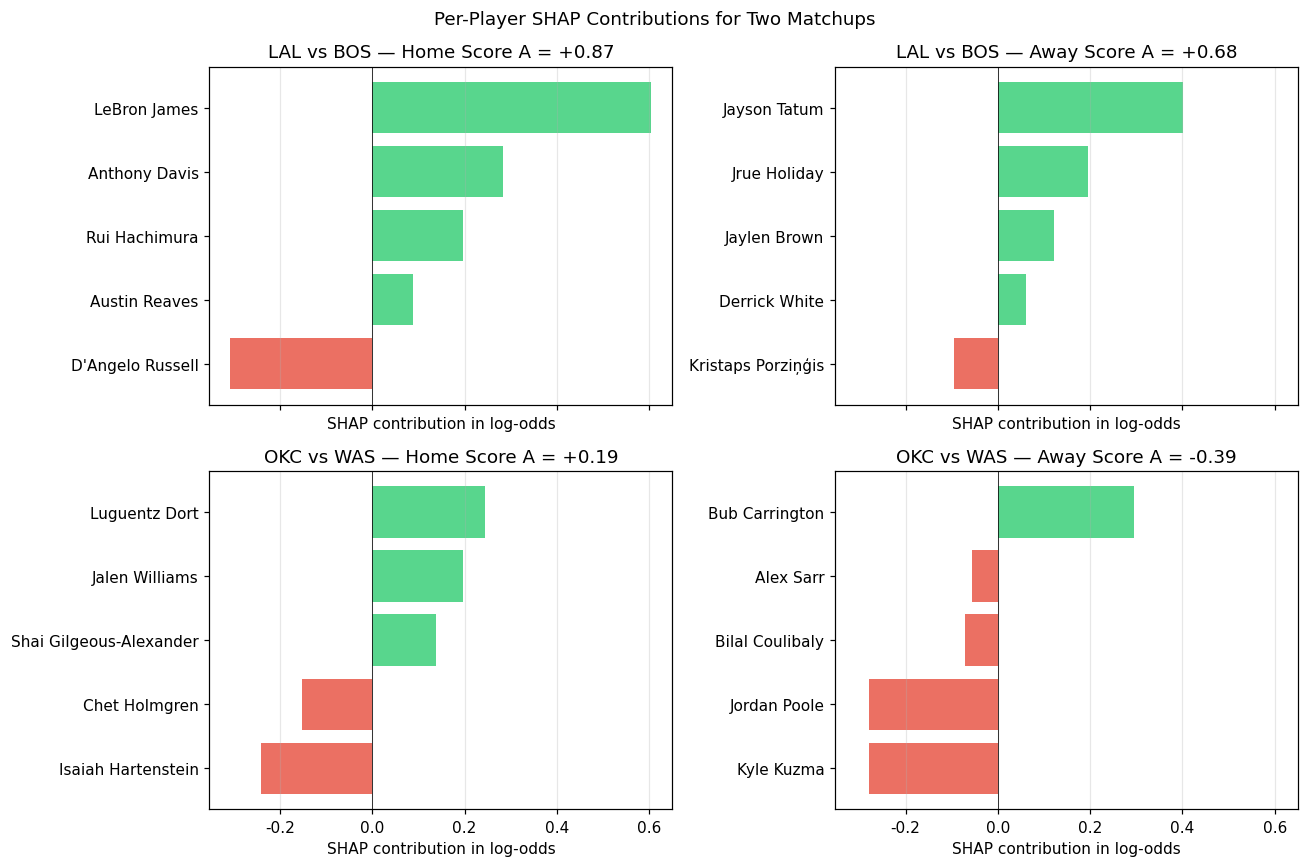

In [6]:
# SHAP explanations for both teams in both matchups.
# Rows are matchups; columns are home/away teams.

fig, axes = plt.subplots(len(matchups), 2, figsize=(12, 8), sharex=True)

for row_idx, item in enumerate(matchups):
    matchup = item['Matchup']
    result_i = results[matchup]

    plot_items = [
        (axes[row_idx, 0], result_i['per_player_shap_home'], f'{matchup} — Home Score A = {result_i["score_A_home"]:+.2f}'),
        (axes[row_idx, 1], result_i['per_player_shap_away'], f'{matchup} — Away Score A = {result_i["score_A_away"]:+.2f}'),
    ]

    for ax, side_df, title in plot_items:
        colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in side_df['shap_sum']]
        ax.barh(side_df['player_name'], side_df['shap_sum'], color=colors, alpha=0.8)
        ax.axvline(0, color='black', lw=0.5)
        ax.set_title(title)
        ax.set_xlabel('SHAP contribution in log-odds')
        ax.invert_yaxis()
        ax.grid(axis='x', alpha=0.3)

fig.suptitle('Per-Player SHAP Contributions for Two Matchups')
fig.tight_layout()


## 2. Player Swap What-If

Replace LeBron James with Luka Doncic and compare the prediction.


In [5]:
home_swap = home_names.copy()
home_swap[0] = 'Doncic'

result_swap = predict_matchup(
    [find_player(n) for n in home_swap],
    away_ids,
    snapshot_date='2025-03-01',
)

swap_summary = pd.DataFrame([
    {'Lineup': 'Original lineup', 'P(home wins)': result['P_home_win']},
    {'Lineup': 'LeBron replaced by Doncic', 'P(home wins)': result_swap['P_home_win']},
])
swap_summary['Change vs original'] = swap_summary['P(home wins)'] - result['P_home_win']

display(swap_summary.round(4))

comparison = pd.DataFrame({
    'Original': summary_table(result).iloc[0],
    'Doncic version': summary_table(result_swap).iloc[0],
})
comparison['Difference'] = comparison['Doncic version'] - comparison['Original']
display(comparison.round(3))


,Lineup,P(home wins),Change vs original
0,Original lineup,0.5945,0.0000
1,LeBron replaced by Doncic,0.5622,-0.0323


,Original,Doncic version,Difference
P_home_win,0.594,0.562,-0.032
Score_A_home,0.865,0.444,-0.421
Score_A_away,0.683,0.683,0.000
ΔA_z,0.123,-0.170,-0.292
Score_B_home,0.153,0.078,-0.075
Score_B_away,0.092,0.092,0.000
ΔB_z,0.143,-0.074,-0.216
Score_C_z,-1.297,-1.457,-0.160
pm_home,5.380,4.960,-0.420
pm_away,4.920,4.920,0.000


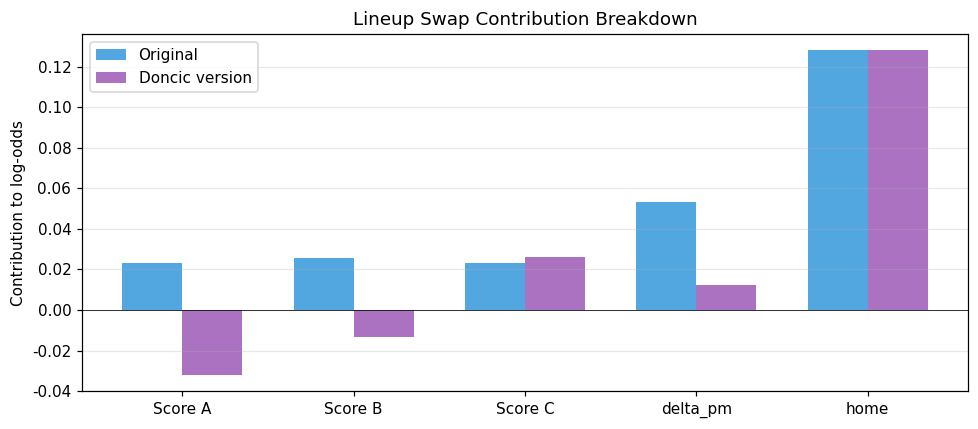

In [6]:
# Visualization: logit contribution changes after the swap.
fig, ax = plt.subplots(figsize=(9, 4))
components = ['from_delta_A', 'from_delta_B', 'from_score_C', 'from_delta_pm', 'from_is_home']
labels = ['Score A', 'Score B', 'Score C', 'delta_pm', 'home']
x = np.arange(len(components))
w = 0.35
ax.bar(x - w/2, [result['logit_contributions'].get(c, 0) for c in components],
       w, label='Original', color='#3498db', alpha=0.85)
ax.bar(x + w/2, [result_swap['logit_contributions'].get(c, 0) for c in components],
       w, label='Doncic version', color='#9b59b6', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=0)
ax.axhline(0, color='black', lw=0.5)
ax.set_ylabel('Contribution to log-odds')
ax.set_title('Lineup Swap Contribution Breakdown')
ax.legend()
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()


## 3. How `outputs/predictions_test.csv` Is Produced

The training script writes one row per 2024-25 hold-out game. Each row stores the raw model scores, their home-minus-away deltas, the standardized final-layer features, and the final probability.

This section reconstructs one row step by step from the saved file, instead of printing hardcoded results.


In [7]:
# Step 1: read the saved hold-out prediction file.
holdout = pd.read_csv('outputs/predictions_test.csv')

column_groups = pd.DataFrame([
    {'Group': 'Game identity', 'Columns': 'game_id, game_date, home_team, away_team'},
    {'Group': 'Score A', 'Columns': 'score_A_home, score_A_away, delta_A_raw, delta_A'},
    {'Group': 'Score B', 'Columns': 'score_B_home, score_B_away, delta_B_raw, delta_B'},
    {'Group': 'Score C', 'Columns': 'score_C_raw, score_C'},
    {'Group': 'Team-strength prior', 'Columns': 'pm_home, pm_away, delta_pm_raw, delta_pm'},
    {'Group': 'Final prediction', 'Columns': 'is_home, home_win, P_home_win, pred_home_win'},
])

display(column_groups)
display(holdout.head(3))


,Group,Columns
0,Game identity,"game_id, game_date, home_team, away_team"
1,Score A,"score_A_home, score_A_away, delta_A_raw, delta_A"
2,Score B,"score_B_home, score_B_away, delta_B_raw, delta_B"
3,Score C,"score_C_raw, score_C"
4,Team-strength prior,"pm_home, pm_away, delta_pm_raw, delta_pm"
5,Final prediction,"is_home, home_win, P_home_win, pred_home_win"


,game_id,game_date,home_team,away_team,score_A_home,score_A_away,delta_A_raw,delta_A,score_B_home,score_B_away,...,score_C_raw,score_C,pm_home,pm_away,delta_pm_raw,delta_pm,is_home,home_win,P_home_win,pred_home_win
0,22400061,2024-10-22,BOS,NYK,1.606084,0.880584,0.725501,0.499865,0.157961,-0.138782,...,0.397044,0.544503,5.033333,4.287500,0.745833,0.168503,1,1,0.639089,1
1,22400062,2024-10-22,LAL,MIN,1.736498,0.867676,0.868822,0.599369,0.189520,0.444199,...,0.643815,1.263884,4.450000,1.800000,2.650000,0.553846,1,1,0.616409,1
2,22400069,2024-10-23,NOP,CHI,-0.227159,0.632741,-0.859900,-0.600835,0.064813,0.054841,...,0.036189,-0.507449,1.425000,-0.877778,2.302778,0.483579,1,1,0.594954,1


In [8]:
# Step 2: choose one hold-out game and verify the home-minus-away raw deltas.
example = holdout.iloc[0].copy()

raw_delta_check = pd.DataFrame([
    {
        'Component': 'Score A',
        'Home value': example['score_A_home'],
        'Away value': example['score_A_away'],
        'Saved raw delta': example['delta_A_raw'],
        'Recomputed raw delta': example['score_A_home'] - example['score_A_away'],
    },
    {
        'Component': 'Score B',
        'Home value': example['score_B_home'],
        'Away value': example['score_B_away'],
        'Saved raw delta': example['delta_B_raw'],
        'Recomputed raw delta': example['score_B_home'] - example['score_B_away'],
    },
    {
        'Component': 'delta_pm',
        'Home value': example['pm_home'],
        'Away value': example['pm_away'],
        'Saved raw delta': example['delta_pm_raw'],
        'Recomputed raw delta': example['pm_home'] - example['pm_away'],
    },
])

display(example[['game_id', 'game_date', 'home_team', 'away_team', 'home_win']].to_frame('Example game'))
display(raw_delta_check.round(6))


,Example game
game_id,22400061
game_date,2024-10-22
home_team,BOS
away_team,NYK
home_win,1


,Component,Home value,Away value,Saved raw delta,Recomputed raw delta
0,Score A,1.606084,0.880584,0.725501,0.725501
1,Score B,0.157961,-0.138782,0.296743,0.296743
2,delta_pm,5.033333,4.287500,0.745833,0.745833


In [9]:
# Step 3: use the standardized final-layer features and final weights to rebuild the logit.
coef_map = {
    'delta_A': weights['alpha_score_A'],
    'delta_B': weights['beta_score_B'],
    'score_C': weights['zeta_score_C'],
    'delta_pm': weights['delta_plus_minus'],
    'is_home': weights['gamma_is_home'],
}

feature_order = ['delta_A', 'delta_B', 'score_C', 'delta_pm', 'is_home']
terms = pd.DataFrame([
    {
        'Feature': feature,
        'Standardized value': example[feature],
        'Coefficient': coef_map[feature],
        'Contribution to logit': example[feature] * coef_map[feature],
    }
    for feature in feature_order
])
intercept = weights['intercept']
logit_rebuilt = terms['Contribution to logit'].sum() + intercept
probability_rebuilt = 1 / (1 + np.exp(-logit_rebuilt))

summary_rebuild = pd.DataFrame([
    {'Quantity': 'Sum(feature contributions)', 'Value': terms['Contribution to logit'].sum()},
    {'Quantity': 'Intercept', 'Value': intercept},
    {'Quantity': 'Rebuilt logit', 'Value': logit_rebuilt},
    {'Quantity': 'Sigmoid(rebuilt logit)', 'Value': probability_rebuilt},
    {'Quantity': 'Saved P_home_win', 'Value': example['P_home_win']},
    {'Quantity': 'Saved pred_home_win', 'Value': example['pred_home_win']},
])

display(terms.round(6))
display(summary_rebuild.round(6))


,Feature,Standardized value,Coefficient,Contribution to logit
0,delta_A,0.499865,0.188511,0.094230
1,delta_B,0.822288,0.181005,0.148838
2,score_C,0.544503,-0.017915,-0.009755
3,delta_pm,0.168503,0.481842,0.081192
4,is_home,1.000000,0.127952,0.127952


,Quantity,Value
0,Sum(feature contributions),0.442457
1,Intercept,0.128956
2,Rebuilt logit,0.571413
3,Sigmoid(rebuilt logit),0.639089
4,Saved P_home_win,0.639089
5,Saved pred_home_win,1.000000


In [10]:
# Step 4: generalize the same calculation to every row in predictions_test.csv.
rebuilt_logits = (
    holdout['delta_A'] * weights['alpha_score_A']
    + holdout['delta_B'] * weights['beta_score_B']
    + holdout['score_C'] * weights['zeta_score_C']
    + holdout['delta_pm'] * weights['delta_plus_minus']
    + holdout['is_home'] * weights['gamma_is_home']
    + weights['intercept']
)
rebuilt_probabilities = 1 / (1 + np.exp(-rebuilt_logits))
rebuilt_predictions = (rebuilt_probabilities >= 0.5).astype(int)

rebuild_check = pd.DataFrame([
    {'Check': 'max |rebuilt P - saved P|', 'Value': np.max(np.abs(rebuilt_probabilities - holdout['P_home_win']))},
    {'Check': 'prediction labels match', 'Value': bool((rebuilt_predictions == holdout['pred_home_win']).all())},
    {'Check': 'rows in predictions_test.csv', 'Value': len(holdout)},
])

display(rebuild_check)


,Check,Value
0,max |rebuilt P - saved P|,0.0
1,prediction labels match,True
2,rows in predictions_test.csv,1225


## 4. Key Talking Points

- The same prediction pipeline runs on both example matchups.
- The same trained final logistic regression weights are used for every matchup.
- Different input features produce different logit contributions and probabilities.
- SHAP plots show player-level Score A contributions for both teams in both matchups.
- `predictions_test.csv` is rebuilt from saved features and weights to verify the final probability calculation.
